In [1]:
import numpy as np
np.random.seed(42)
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
train_file = 'training files/emnist-balanced-train.csv'
train_df = pd.read_csv(train_file, header=None)
test_file = 'training files/emnist-balanced-test.csv'
test_df = pd.read_csv(test_file, header=None)

In [3]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,45,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,44,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
image_size = (28, 28)

In [24]:
def transform_images(images):
    images = images.reshape(images.shape[0], image_size[0], image_size[1]).astype(float)
    images /= 255
    images = np.fliplr(images)
    images = np.rot90(images, -1, axes=[1, 2])
    return images

In [25]:
X_train = train_df.drop(columns=[0]).values
X_train = transform_images(X_train)
y_train = train_df[0].values

In [26]:
X_test = test_df.drop(columns=[0]).values
X_test = transform_images(X_test)
y_test = test_df[0].values

In [5]:
mapping_file = 'training files/mapping.txt'
mapping = {}
with open(mapping_file, 'r') as file:
    lines = file.read().strip().split('\n')
    for line in lines:
        key, value = map(int, line.split())
        mapping[key] = value
mapping

{0: 48,
 1: 49,
 2: 50,
 3: 51,
 4: 52,
 5: 53,
 6: 54,
 7: 55,
 8: 56,
 9: 57,
 10: 65,
 11: 66,
 12: 67,
 13: 68,
 14: 69,
 15: 70,
 16: 71,
 17: 72,
 18: 73,
 19: 74,
 20: 75,
 21: 76,
 22: 77,
 23: 78,
 24: 79,
 25: 80,
 26: 81,
 27: 82,
 28: 83,
 29: 84,
 30: 85,
 31: 86,
 32: 87,
 33: 88,
 34: 89,
 35: 90,
 36: 97,
 37: 98,
 38: 100,
 39: 101,
 40: 102,
 41: 103,
 42: 104,
 43: 110,
 44: 113,
 45: 114,
 46: 116}

In [10]:
def display_image(ax, image_idx):
    ax.imshow(X_train[image_idx], cmap='gray')
    ax.set_title(f'image: {image_idx}, label: {chr(mapping[y_train[image_idx]])}')
    ax.axis('off');

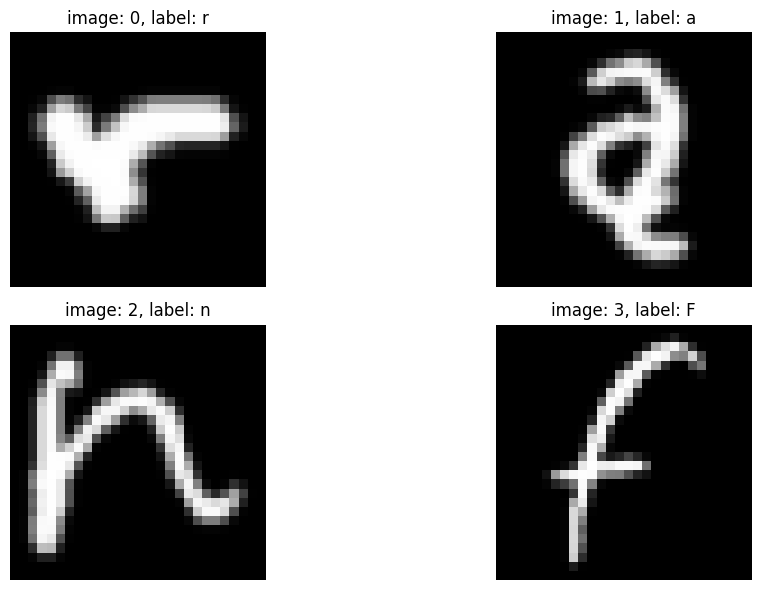

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))

display_image(ax[0, 0], 0)
display_image(ax[0, 1], 1)
display_image(ax[1, 0], 2)
display_image(ax[1, 1], 3)
plt.tight_layout()

In [12]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
y_train_ohe = ohe.fit_transform(y_train.reshape(y_train.shape[0], 1))
y_test_ohe = ohe.transform(y_test.reshape(y_test.shape[0], 1))
y_train_ohe.shape, y_test_ohe.shape

((112800, 47), (18800, 47))

In [29]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout, Dense
from tensorflow.random import set_seed
set_seed(42)

batch_size=128

model = Sequential([
    Input((image_size[0], image_size[1], 1), batch_size=batch_size),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(len(mapping), activation='softmax')
])

In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (128, 26, 26, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (128, 13, 13, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (128, 11, 11, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (128, 5, 5, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (128, 1600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (128, 1600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (128, 1024)            │     1,639,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (128, 1024)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (128, 512)             │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (128, 47)              │        24,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,207,151 (8.42 MB)

 Trainable params: 2,207,151 (8.42 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [33]:
history = model.fit(
    X_train,
    y_train_ohe,
    epochs=50,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5859 - loss: 1.4417 - val_accuracy: 0.8455 - val_loss: 0.4386
Epoch 2/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8162 - loss: 0.5334 - val_accuracy: 0.8639 - val_loss: 0.3800
Epoch 3/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8398 - loss: 0.4555 - val_accuracy: 0.8715 - val_loss: 0.3551
Epoch 4/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8533 - loss: 0.4124 - val_accuracy: 0.8748 - val_loss: 0.3447
Epoch 5/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8593 - loss: 0.3883 - val_accuracy: 0.8806 - val_loss: 0.3270
Epoch 6/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8646 - loss: 0.3760 - val_accuracy: 0.8798 - val_loss: 0.3264
Epoch 7/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8684 - loss: 0.3596 - val_accuracy: 0.8808 - val_loss: 0.3217
Epoch 8/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8719 - loss: 0.3450 - val_accuracy: 

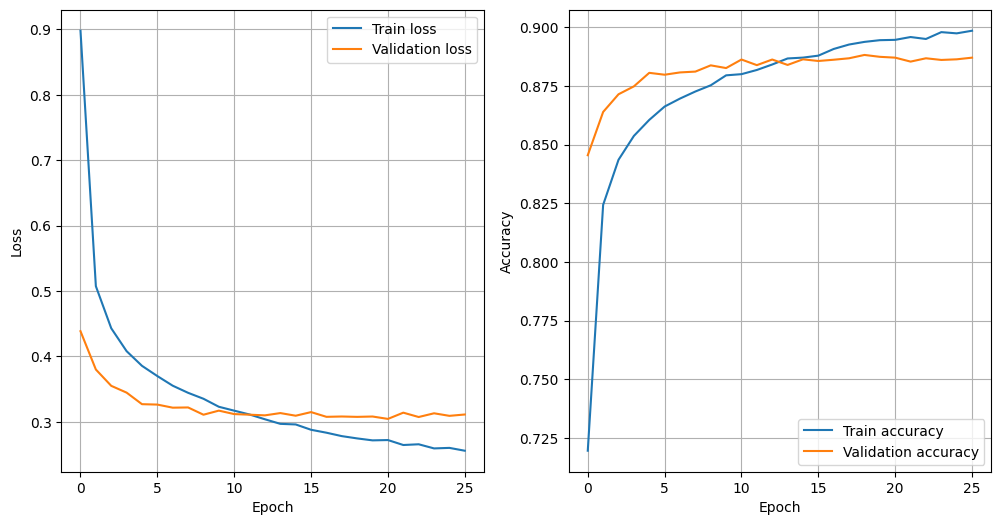

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(history.epoch, history.history['loss'], label='Train loss')
ax[0].plot(history.epoch, history.history['val_loss'], label='Validation loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid()
ax[0].legend()

ax[1].plot(history.epoch, history.history['accuracy'], label='Train accuracy')
ax[1].plot(history.epoch, history.history['val_accuracy'], label='Validation accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].grid()
ax[1].legend();

In [35]:
model.evaluate(X_test, y_test_ohe, batch_size=batch_size)

147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8926 - loss: 0.3134


[0.3130885064601898, 0.8919149041175842]

In [36]:
model.save('model.keras')